<a href="https://colab.research.google.com/github/riyautekar25/ML-projects/blob/branch1/Credit_card_fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Credit Card Fraud Detection - Full Project Notebook

# ===============================
# 1. Imports and Setup
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

In [2]:
# ===============================
# 2. Load Data
# ===============================
train_df = pd.read_csv('fraudTrain.csv')
test_df = pd.read_csv('fraudTest.csv')

print(f"Train shape: {train_df.shape}, Test shape: {test_df.shape}")
train_df.head()

Train shape: (1296675, 23), Test shape: (555719, 23)


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [3]:
# ===============================
# 3. Data Preprocessing
# ===============================

# Drop unnamed column if present
if 'Unnamed: 0' in train_df.columns:
    train_df.drop(columns=['Unnamed: 0'], inplace=True)
    test_df.drop(columns=['Unnamed: 0'], inplace=True)

# Check for nulls
print(train_df.isnull().sum())

trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64


In [4]:
# Convert datetime
# Check if 'trans_date_trans_time' column exists before processing
if 'trans_date_trans_time' in train_df.columns:
    train_df['trans_date_trans_time'] = pd.to_datetime(train_df['trans_date_trans_time'])
    test_df['trans_date_trans_time'] = pd.to_datetime(test_df['trans_date_trans_time'])

    # Create new time-based features
    def create_time_features(df):
        df['hour'] = df['trans_date_trans_time'].dt.hour
        df['day'] = df['trans_date_trans_time'].dt.day
        df['weekday'] = df['trans_date_trans_time'].dt.weekday
        df.drop(columns=['trans_date_trans_time'], inplace=True)
        return df

    train_df = create_time_features(train_df)
    test_df = create_time_features(test_df)
else:
    print("Column 'trans_date_trans_time' not found. Skipping datetime conversion.")

# Label encode categorical features
cat_cols = ['category', 'gender', 'state', 'job', 'merchant']
le = LabelEncoder()

for col in cat_cols:
    # Convert all values to strings before fitting LabelEncoder
    train_df[col] = train_df[col].astype(str)
    test_df[col] = test_df[col].astype(str)

    all_values = pd.concat([train_df[col], test_df[col]]).unique()
    le.fit(all_values)
    train_df[col] = le.transform(train_df[col])
    test_df[col] = le.transform(test_df[col])
# Drop unnecessary columns
# This code should be run after working with trans_date_trans_time column.
# Make sure it is executed after you execute the cells for Convert datetime & Create new time-based features steps
cols_to_drop = ['cc_num', 'first', 'last', 'street', 'city', 'zip', 'dob', 'trans_num', 'unix_time', 'merch_lat', 'merch_long']
train_df.drop(columns=cols_to_drop, inplace=True)
test_df.drop(columns=cols_to_drop, inplace=True)

In [5]:
# ===============================
# 4. Prepare Data for Modeling
# ===============================
X_train = train_df.drop(columns=['is_fraud'])
y_train = train_df['is_fraud']

X_test = test_df.drop(columns=['is_fraud'])
y_test = test_df['is_fraud']

# Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
# ===============================
# 5. Train Models
# ===============================

models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    print(classification_report(y_test, y_pred))
    auc = roc_auc_score(y_test, y_proba)
    results[name] = {'model': model, 'roc_auc': auc}
    print(f"ROC-AUC: {auc:.4f}")


Training Logistic Regression...
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.00      0.00      0.00      2145

    accuracy                           1.00    555719
   macro avg       0.50      0.50      0.50    555719
weighted avg       0.99      1.00      0.99    555719

ROC-AUC: 0.8336

Training Random Forest...
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.91      0.65      0.76      2145

    accuracy                           1.00    555719
   macro avg       0.95      0.83      0.88    555719
weighted avg       1.00      1.00      1.00    555719

ROC-AUC: 0.9719

Training XGBoost...
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.84      0.58      0.68      2145

    accuracy                           1.00    555719
   macro avg   

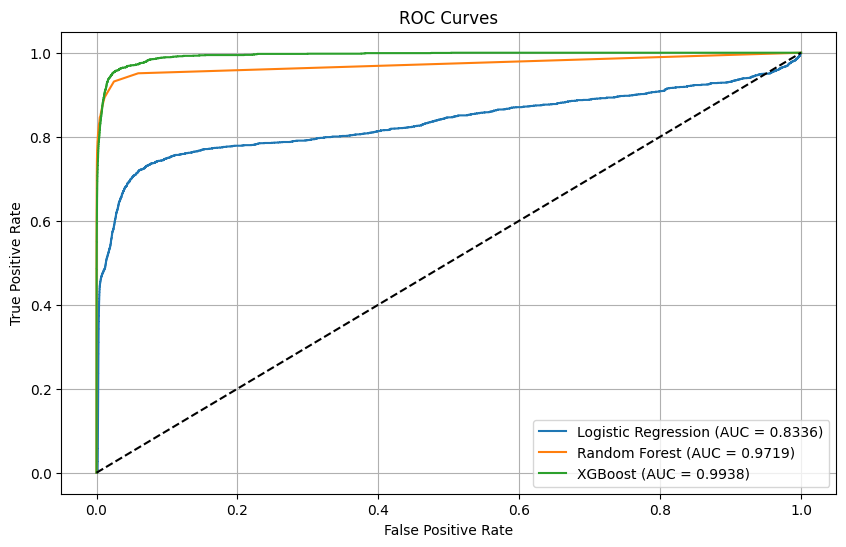

In [7]:
# ===============================
# 6. Plot ROC Curves
# ===============================
plt.figure(figsize=(10, 6))
for name, res in results.items():
    model = res['model']
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {res['roc_auc']:.4f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curves')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid()
plt.show()

In [8]:
# ===============================
# 7. Final Comparison
# ===============================
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'ROC-AUC': [results[m]['roc_auc'] for m in results]
}).sort_values(by='ROC-AUC', ascending=False)

print("\nModel Performance Comparison:")
print(comparison_df)


Model Performance Comparison:
                 Model   ROC-AUC
2              XGBoost  0.993759
1        Random Forest  0.971908
0  Logistic Regression  0.833640
